<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Visión por Computadora II
## Detección en imágenes fisheye: rama 2, proyección cilíndrica

### Objetivo

Las cámaras de surround view usan lentes ojo de pez con una distorsión radial muy fuerte. Las convoluciones son equivariantes a traslaciones, o sea que el mismo patrón da la misma respuesta en cualquier parte de la imagen. En una fisheye eso deja de servir, porque un peatón en el centro y el mismo peatón en la periferia tienen geometrías distintas, y los detectores pre-entrenados en COCO no fueron entrenados con esa deformación.

En este notebook trabajo la segunda estrategia del diagrama. La idea es no tocar el modelo y en cambio corregir la imagen:

1. Proyecto cada imagen fisheye a coordenadas cilíndricas usando la calibración de WoodScape. En la proyección cilíndrica las verticales del mundo quedan verticales y los objetos se parecen más a lo que vería una cámara en perspectiva.
2. Detecto con modelos pre-entrenados en COCO (YOLO11 de varios tamaños, Faster R-CNN y Mask R-CNN), sin fine-tuning.
3. Llevo las cajas de vuelta a la imagen fisheye, para evaluar contra el mismo ground truth que las otras dos ramas.

![flujo](../vpc2_fisheye.png)

Mido mAP@50, mAP@50-95, mAP estratificado por excentricidad radial (centro, medio y periferia) y la latencia de cada etapa.

### Imports y constantes

In [1]:
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # algunas ops de torchvision no tienen kernel en mps

import sys
import time
from functools import partial
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import supervision as sv
import torch
import torchvision
from tqdm.auto import tqdm

tqdm = partial(tqdm, mininterval=30)  # sin esto la barra deja miles de lineas en el notebook guardado

# las funciones compartidas por las tres ramas estan en fisheye_utils.py, en la raiz del repo
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from fisheye_utils import (
    ANILLOS, CLASES, CONF, DEVICE, ELEV_ABAJO, ELEV_ARRIBA, HFOV, IMGSZ, MODELOS, NOMBRES_ANILLOS, VFOV,
    a_clases_tp, caja_a_fisheye, cargar_test, cilindrica, dibujar, evaluar, mapas, radio, tabla_resultados,
)

/Users/francomorero/PycharmProjects/franco/vision-computadora-II-tp-final/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SALIDAS = RAIZ / "outputs/rama2"
SALIDAS.mkdir(parents=True, exist_ok=True)
N_IMAGENES = None  # un entero para pruebas rapidas, None para todo el test
SEMILLA = 42

print(f"device: {DEVICE} | torch {torch.__version__} | torchvision {torchvision.__version__} | supervision {sv.__version__}")
print(f"imgsz: {IMGSZ} | conf: {CONF} | hfov: {np.rad2deg(HFOV):.0f} | vfov: {np.rad2deg(VFOV):.0f} | banda: +{np.rad2deg(ELEV_ARRIBA):.0f}/-{np.rad2deg(ELEV_ABAJO):.0f}")

device: mps | torch 2.14.0 | torchvision 0.29.0 | supervision 0.30.5
imgsz: 640 | conf: 0.01 | hfov: 190 | vfov: 143 | banda: +45/-45


### Carga del test y ground truth

Uso las 1000 imágenes de test del Drive del equipo, así evaluamos las tres ramas sobre archivos idénticos. El ground truth lo arma `cargar_test` con las mismas funciones de `CV2/Scripts/convert_to_yolo.py` y el mismo `class_map.json`: caja = mínimo y máximo del polígono, recortada al borde, y descarto las de menos de 300 px² o con un lado menor a 8 px. Si armara el GT por mi cuenta, las métricas no serían comparables con las de las otras ramas.

In [3]:
test = cargar_test(N_IMAGENES)
print(f"clases: {CLASES} | cajas de gt: {sum(len(c) for c in test['gt_clases'])}")

pd.DataFrame({
    "imagenes": test.groupby("camera").size(),
    **{c: test.groupby("camera")["gt_clases"].apply(lambda s, i=i: sum((x == i).sum() for x in s)) for i, c in enumerate(CLASES)},
})

test: 1000 imagenes en el manifest | presentes: 1000 | faltan 0


clases: ['vehicle', 'person', 'two_wheeler'] | cajas de gt: 11910


,imagenes,vehicle,person,two_wheeler
camera,,,,
FV,247,1351,747,640
MVL,251,2080,611,502
MVR,261,1635,779,808
RV,241,1456,649,652


### Proyección cilíndrica

WoodScape trae un archivo de calibración por imagen, con la intrínseca (polinomio de 4to orden `rho(theta) = k1·θ + k2·θ² + k3·θ³ + k4·θ⁴`, centro óptico) y la extrínseca (cuaternión cámara → vehículo). Si falta la calibración de una imagen, uso la de otra imagen de la misma cámara, porque el rig es el mismo y los parámetros apenas cambian.

La proyección es la del tutorial de Plaut et al. (https://plaut.github.io/fisheye_tutorial/). Para cada píxel de la imagen cilíndrica calcula el rayo 3D, lo rota para que el cilindro quede vertical respecto al piso y lo proyecta sobre la fisheye con el modelo de la lente. El resultado son dos mapas `mapx, mapy` que dicen de qué píxel fisheye sale cada píxel cilíndrico. Las dos funciones están en `fisheye_utils.py` tal cual las pasamos.

Con el campo vertical de 143° la cilíndrica queda de 1124×2026 y casi tres cuartos de la imagen son asfalto estirado y la carrocería propia, porque las cámaras miran hacia abajo. Los objetos quedan en una franja chica cerca del horizonte, y cuando el detector escala a `IMGSZ` se vuelven diminutos. Además el capó propio genera detecciones falsas de `vehicle` enormes.

Por eso me quedo con una banda de ±45° alrededor del horizonte (`ELEV_ARRIBA`, `ELEV_ABAJO`). El criterio lo elegi porque un peatón de 1,8 m parado a más de 1,5 m de una cámara montada entre 0,6 y 1 m de altura entra en la banda. La imagen queda de 1124×~680, con una relación de aspecto parecida a la fisheye. La fila del horizonte la calcula `fila_horizonte` con las mismas cuentas de `get_mapping`: en el cilindro vertical el horizonte cae en la fila `cy` de la matriz `K`.

`get_mapping` tarda casi un segundo por imagen, porque arma un rayo para cada uno de los ~2 millones de píxeles. Como la calibración casi no cambia dentro de una cámara, cacheo los mapas por calibración. Así el preprocesamiento por imagen se reduce al `cv2.remap`, que es lo que correría en la ECU con los mapas precalculados.

In [4]:
print(f"calibraciones propias: {test['calib_propia'].sum()} | de su camara: {(~test['calib_propia']).sum()} | distintas: {test['calib'].nunique()}")

calibraciones propias: 1000 | de su camara: 0 | distintas: 101


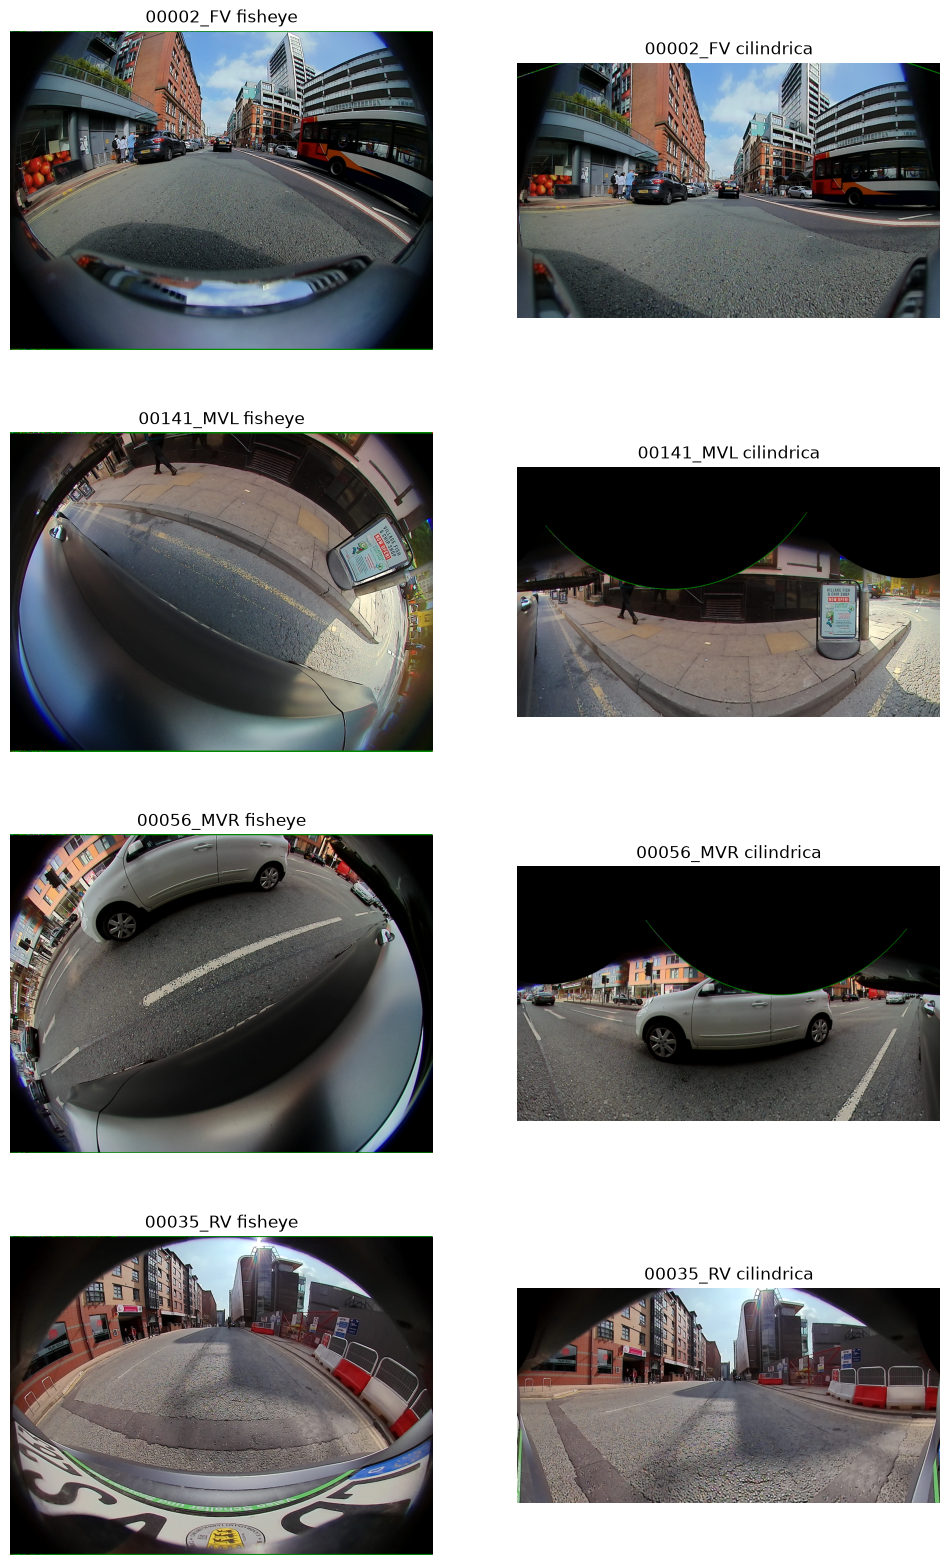

fisheye: 1280x966 | cilindrica: 1124x572


In [5]:
ejemplos = test.groupby("camera").head(1)
imgs, titulos = [], []
for fila in ejemplos.itertuples():
    img = cv2.imread(str(fila.ruta))
    imgs += [img, cilindrica(fila, img)]
    titulos += [f"{fila.stem} fisheye", f"{fila.stem} cilindrica"]
sv.plot_images_grid(imgs, grid_size=(4, 2), titles=titulos, size=(12, 20))
print(f"fisheye: {img.shape[1]}x{img.shape[0]} | cilindrica: {imgs[-1].shape[1]}x{imgs[-1].shape[0]}")

El recorte tiene un costo, los objetos que quedan fuera de la banda (muy cerca de la cámara o fuera del campo horizontal de 190°) no se pueden detectar en esta rama. Cuento cuántas cajas del ground truth tienen su centro fuera de la zona que cubre la cilíndrica, ese número es el techo de recall de la rama 2 y hay que reportarlo en el paper.

In [6]:
def cubiertas(fila):
    """mascara de cajas del gt cuyo centro cae en la zona de la fisheye que ve la cilindrica"""
    mx, my = mapas(fila.calib)
    zona = np.zeros((int(fila.H), int(fila.W)), dtype=np.uint8)
    ok = (mx >= 0) & (mx < fila.W - 1) & (my >= 0) & (my < fila.H - 1)
    zona[np.round(my[ok]).astype(int), np.round(mx[ok]).astype(int)] = 1
    zona = cv2.dilate(zona, np.ones((5, 5), np.uint8))  # tapo los huecos del muestreo
    c = fila.gt_cajas
    cx, cy = ((c[:, 0] + c[:, 2]) / 2).astype(int), ((c[:, 1] + c[:, 3]) / 2).astype(int)
    return zona[np.clip(cy, 0, zona.shape[0] - 1), np.clip(cx, 0, zona.shape[1] - 1)] > 0


test["gt_cubiertas"] = [cubiertas(f) for f in tqdm(test.itertuples(), total=len(test), desc="cobertura")]
cob = pd.DataFrame({"camara": np.repeat(test["camera"], test["gt_clases"].map(len)),
                    "clase": [CLASES[c] for c in np.concatenate(test["gt_clases"].tolist())],
                    "cubierta": np.concatenate(test["gt_cubiertas"].tolist())})
print(f"cajas del gt dentro de la cilindrica: {cob['cubierta'].mean():.1%}")
cob.pivot_table(index="camara", columns="clase", values="cubierta", aggfunc="mean").round(3)


cobertura:   0%|          | 0/1000 [00:00<?, ?it/s]


cobertura: 100%|██████████| 1000/1000 [00:28<00:00, 34.66it/s]

cajas del gt dentro de la cilindrica: 95.7%


clase,person,two_wheeler,vehicle
camara,,,
FV,1.000,1.000,1.000
MVL,0.985,0.992,0.912
MVR,0.963,0.991,0.828
RV,1.000,1.000,1.000


Observaciones:
* En la cilíndrica los postes, las columnas y los bordes de los autos vuelven a ser verticales, que es la geometría que el detector aprendió en COCO.
* En los bordes horizontales, por encima de ±90° respecto del eje de la cámara, la cilíndrica estira mucho la imagen. Ahí la resolución efectiva es menor que en el centro.
* Los bordes negros son píxeles que caen fuera del círculo de la lente.

### Post-procesamiento: de la cilíndrica a la fisheye

Para comparar contra el ground truth tengo que llevar cada caja detectada a la imagen original. `mapx, mapy` ya dan la correspondencia píxel a píxel, así que no hace falta invertir el modelo de la lente. Muestreo el perímetro de la caja en la cilíndrica, busco a qué punto fisheye corresponde cada punto y me quedo con el mínimo y el máximo. Como la proyección es continua, el interior de la caja cae dentro de ese contorno, entonces alcanza con el perímetro.

La caja resultante es axis-aligned, igual que el ground truth. En la periferia el contorno queda curvo y la caja que lo encierra es más grande que el objeto, lo que le baja el IoU a esta rama en la periferia, que es justamente la zona que queremos medir. Las cajas rotadas o poligonales quedan como extensión, como sugirió el profe.

In [7]:
# chequeo: una caja chica alrededor de un pixel valido tiene que contener su punto fisheye
fila = test.iloc[0]
mx, my = mapas(fila.calib)
fi, ci = mx.shape[0] // 2, mx.shape[1] // 2
caja, ok = caja_a_fisheye(np.array([[ci - 10, fi - 10, ci + 10, fi + 10]]), mx, my, fila.W, fila.H)
assert ok[0] and caja[0, 0] <= mx[fi, ci] <= caja[0, 2] and caja[0, 1] <= my[fi, ci] <= caja[0, 3]
assert caja[0, 2] - caja[0, 0] < 60, "una caja de 20 px no deberia volverse enorme en el centro"
print(f"caja cilindrica [{ci-10}, {fi-10}, {ci+10}, {fi+10}] -> fisheye {caja[0].round(1)}")

caja cilindrica [553, 330, 573, 350] -> fisheye [      632.9       335.3       653.3       355.3]


### Modelos

Los detectores están entrenados en COCO, así que traduzco sus clases a las del TP y descarto el resto:

| COCO | TP |
|---|---|
| car, bus, truck | vehicle |
| person | person |
| bicycle, motorcycle | two_wheeler |

Uso dos familias:
* YOLO11 en los cinco tamaños (n, s, m, l, x). Es de una etapa y es el tipo de modelo que se usaría en una ECU. Probando todos los tamaños obtengo la curva de precisión contra latencia.
* Faster R-CNN y Mask R-CNN de torchvision, que son de dos etapas. De Mask R-CNN solo uso las cajas, pero mido su tiempo completo porque la cabeza de máscaras corre igual. R-CNN y Fast R-CNN no están en torchvision, porque dependen de selective search para proponer regiones, tardan segundos por imagen y quedaron obsoletos. Faster R-CNN representa a esa familia, con la RPN en lugar de selective search. Sumo también la versión con MobileNetV3 para tener un modelo liviano de dos etapas.

In [8]:
print(f"modelos: {list(MODELOS)}")

modelos: ['yolo11n', 'yolo11s', 'yolo11m', 'yolo11l', 'yolo11x', 'fasterrcnn_mobilenet_v3', 'fasterrcnn_r50_v2', 'maskrcnn_r50_v2']


### Inferencia sobre todo el test

Por cada imagen mido por separado las tres etapas del flujo, en milisegundos:
* pre: el `cv2.remap` a cilíndrica, con los mapas ya calculados.
* inf: el detector completo, con su propio resize, NMS y la copia a CPU. La copia obliga a esperar a que la GPU termine, entonces el tiempo medido incluye todo el cómputo.
* post: filtrar las clases y reproyectar las cajas.

Antes de medir hago diez pasadas de calentamiento, porque la primera inferencia en MPS compila kernels y tarda varias veces más. Las predicciones se guardan en `outputs/rama2/` para no tener que repetir la corrida si se reinicia el kernel.

In [9]:
def predecir(nombre):
    """corre un modelo sobre todo el test y devuelve un dataframe con cajas y tiempos por imagen"""
    ruta = SALIDAS / f"preds_{nombre}_{len(test)}.pkl"
    if ruta.exists():
        return pd.read_pickle(ruta)
    detectar, coco = MODELOS[nombre]()
    cil0 = cilindrica(test.iloc[0])
    for _ in range(10):
        detectar(cil0)

    filas = []
    for fila in tqdm(test.itertuples(), total=len(test), desc=nombre):
        img = cv2.imread(str(fila.ruta))
        t0 = time.perf_counter()
        cil = cilindrica(fila, img)
        t1 = time.perf_counter()
        xyxy, conf, cls = detectar(cil)
        t2 = time.perf_counter()
        xyxy, conf, cls = a_clases_tp(xyxy, conf, cls, coco)
        fish, ok = caja_a_fisheye(xyxy, *mapas(fila.calib), fila.W, fila.H)
        t3 = time.perf_counter()
        filas.append({"stem": fila.stem, "cajas_cil": xyxy, "conf_cil": conf, "clases_cil": cls, "cajas": fish[ok], "conf": conf[ok], "clases": cls[ok],
                      "ms_pre": 1e3 * (t1 - t0), "ms_inf": 1e3 * (t2 - t1), "ms_post": 1e3 * (t3 - t2)})
    preds = pd.DataFrame(filas)
    preds.to_pickle(ruta)
    return preds


for fila in test.drop_duplicates("calib").itertuples():
    mapas(fila.calib)  # calculo los mapas antes, asi no ensucian la latencia
preds = {nombre: predecir(nombre) for nombre in MODELOS}


yolo11n:   0%|          | 0/1000 [00:00<?, ?it/s]


yolo11n:  69%|██████▉   | 692/1000 [00:30<00:13, 23.05it/s]


yolo11n:  69%|██████▉   | 692/1000 [00:40<00:13, 23.05it/s]


yolo11n: 100%|██████████| 1000/1000 [00:43<00:00, 22.91it/s]


yolo11s:   0%|          | 0/1000 [00:00<?, ?it/s]

...


maskrcnn_r50_v2:  88%|████████▊ | 883/1000 [10:52<01:22,  1.42it/s]


maskrcnn_r50_v2:  93%|█████████▎| 926/1000 [11:06<00:52,  1.42it/s]


maskrcnn_r50_v2:  93%|█████████▎| 926/1000 [11:22<00:52,  1.42it/s]


maskrcnn_r50_v2:  98%|█████████▊| 975/1000 [11:36<00:16,  1.47it/s]


maskrcnn_r50_v2: 100%|██████████| 1000/1000 [11:51<00:00,  1.41it/s]

### Visualización

Muestro una imagen por cámara con tres paneles: el ground truth sobre la fisheye, las detecciones sobre la cilíndrica y las mismas detecciones reproyectadas a la fisheye. Uso YOLO11m y un umbral de 0.3 solo para que el dibujo se lea. Las métricas usan todas las cajas.

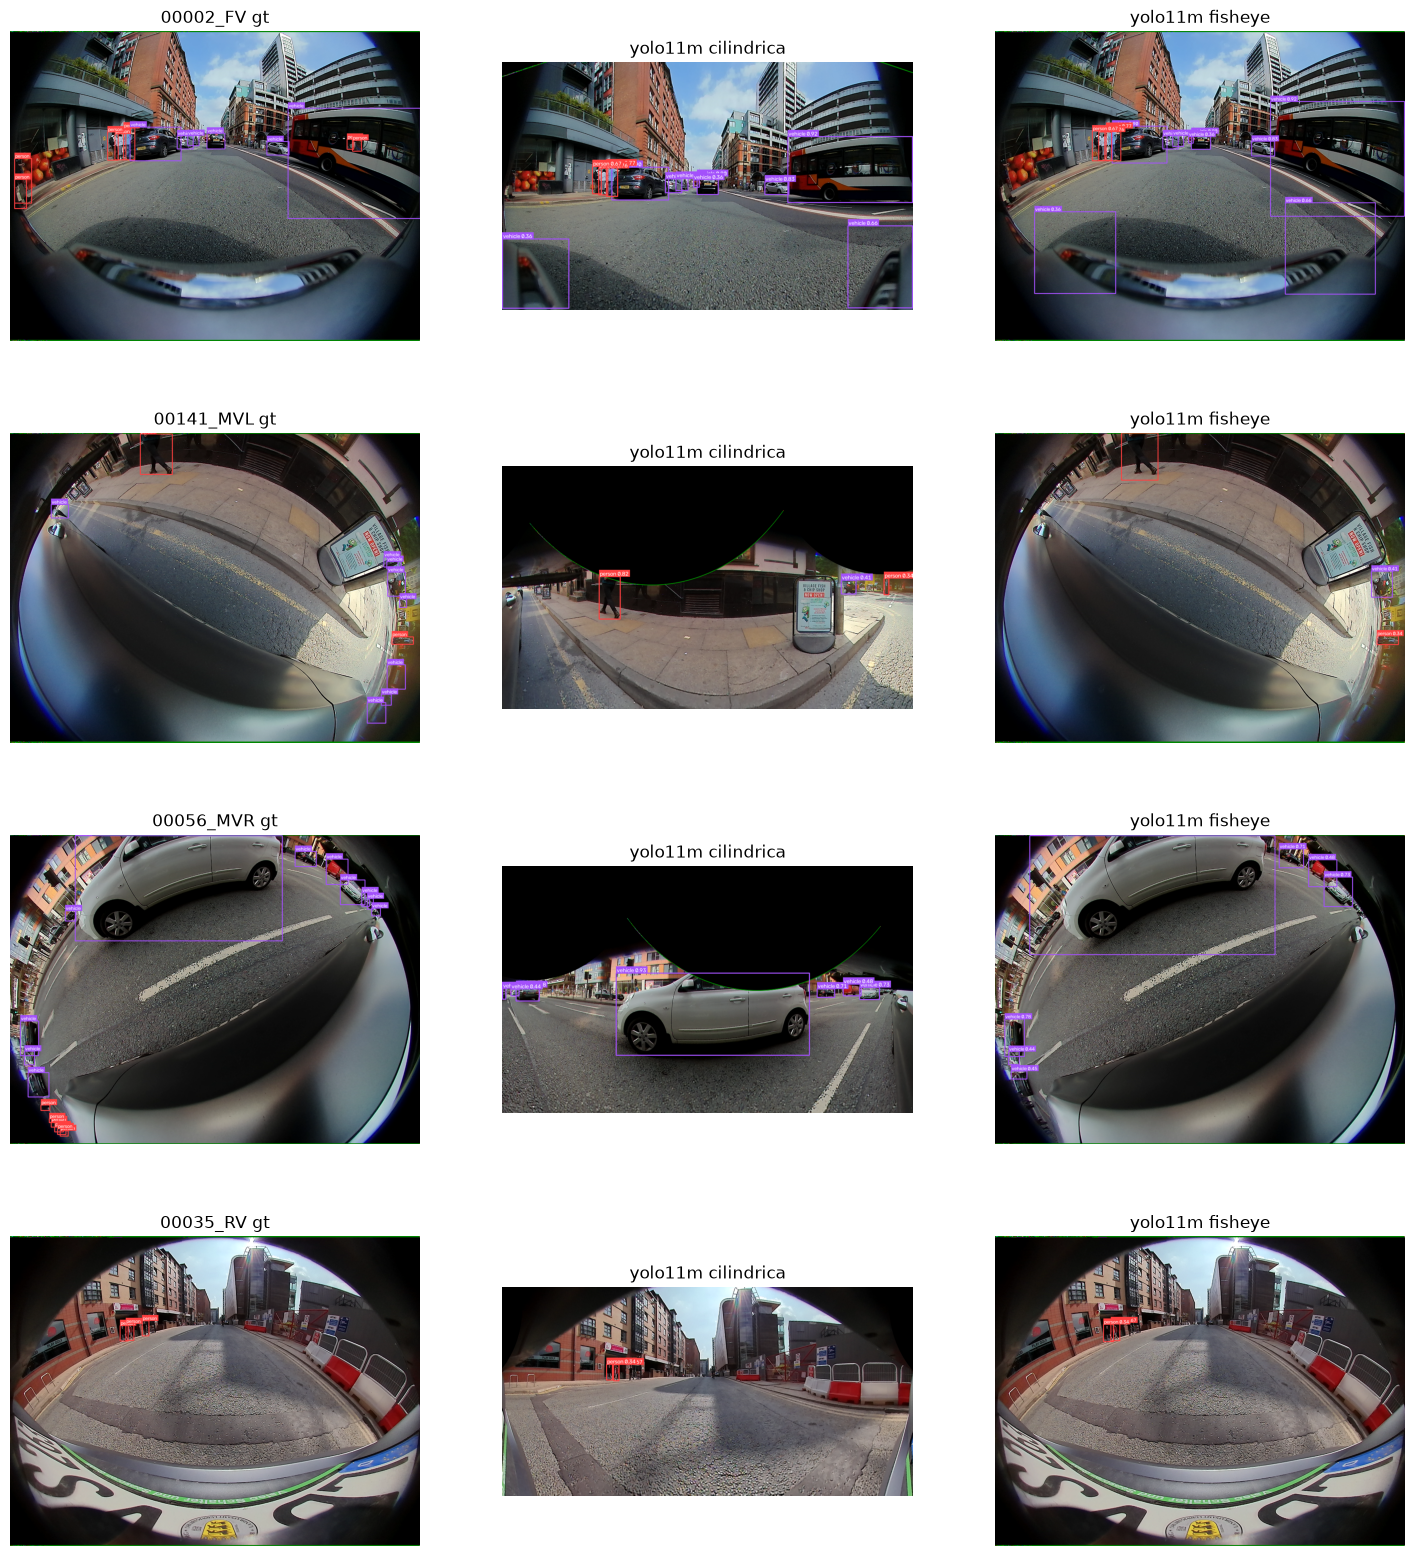

In [10]:
MODELO_VIS, CONF_VIS = "yolo11m", 0.3
def paneles(fila, p):
    """gt en fisheye | pred en cilindrica | pred reproyectada"""
    img = cv2.imread(str(fila.ruta))
    m, mc = p["conf"] >= CONF_VIS, p["conf_cil"] >= CONF_VIS
    cil = dibujar(cilindrica(fila, img), p["cajas_cil"][mc], p["clases_cil"][mc], p["conf_cil"][mc])
    return [dibujar(img, fila.gt_cajas, fila.gt_clases), cil, dibujar(img, p["cajas"][m], p["clases"][m], p["conf"][m])]


pv = preds[MODELO_VIS].set_index("stem")
imgs, titulos = [], []
for fila in ejemplos.itertuples():
    imgs += paneles(fila, pv.loc[fila.stem])
    titulos += [f"{fila.stem} gt", f"{MODELO_VIS} cilindrica", f"{MODELO_VIS} fisheye"]
sv.plot_images_grid(imgs, grid_size=(4, 3), titles=titulos, size=(18, 20))

Observaciones:
* Las cajas reproyectadas caen sobre los objetos y en la periferia se ven más anchas que las del ground truth, por el contorno curvo que mencioné antes.
* En la FV sigue habiendo falsos `vehicle` sobre la carrocería propia, en las esquinas inferiores de la banda. Una máscara del ego-vehículo por cámara los sacaría, pero la dejo afuera para no meter una segunda modificación en la rama.
* En las laterales la parte de arriba de la banda queda negra, porque la cámara mira hacia abajo y el cielo cae fuera del círculo de la lente.

Guardo además una muestra cada 50 imágenes en `outputs/rama2/vis/` (ground truth a la izquierda y predicción a la derecha) para recorrer el test completo y ver cómo va quedando.

In [11]:
(SALIDAS / "vis").mkdir(exist_ok=True)
for fila in test.iloc[::50].itertuples():
    gt, _, pred = paneles(fila, pv.loc[fila.stem])
    cv2.imwrite(str(SALIDAS / "vis" / f"{fila.stem}_{MODELO_VIS}.jpg"), np.hstack([gt, pred]))
print(f"guardadas {len(test.iloc[::50])} imagenes en {SALIDAS / 'vis'}")

guardadas 20 imagenes en /Users/francomorero/PycharmProjects/franco/vision-computadora-II-tp-final/outputs/rama2/vis


### Métricas

Uso `MeanAveragePrecision` de supervision, que calcula mAP@50 y mAP@50-95 al estilo COCO. Antes de confiar en los números pruebo la función con el propio ground truth como predicción, y tiene que dar 1.

Para el mAP estratificado por excentricidad calculo, para cada caja, la distancia de su centro al centro óptico de la imagen (sale de la calibración, no del centro geométrico), normalizada por la media diagonal. Con eso separo tres anillos, centro, medio y periferia. En cada anillo filtro tanto el ground truth como las predicciones y calculo el mAP. Si la proyección cilíndrica sirve, la caída del centro a la periferia tendría que ser menor que en el baseline de la rama 1.

In [12]:
# chequeo: el gt como prediccion tiene que dar 1
gt_como_pred = pd.DataFrame({"stem": test["stem"], "cajas": test["gt_cajas"], "clases": test["gt_clases"],
                             "conf": [np.ones(len(c), dtype=np.float32) for c in test["gt_clases"]]})
m50, m5095 = evaluar(gt_como_pred, test)
assert m50 > 0.99 and m5095 > 0.99, (m50, m5095)
print(f"gt vs gt: map50={m50:.3f} | map50-95={m5095:.3f}")

# cuantas cajas de gt hay en cada anillo
r_gt = np.concatenate([radio(f.gt_cajas, f) for f in test.itertuples()])
print(pd.cut(r_gt, ANILLOS, labels=NOMBRES_ANILLOS, right=False).value_counts().sort_index())

gt vs gt: map50=1.000 | map50-95=1.000
centro       1887
medio        6656
periferia    3367
Name: count, dtype: int64


In [13]:
resultados = tabla_resultados(preds, test)
resultados.to_csv(SALIDAS / "resultados.csv")
resultados.round(3)

,mAP50,mAP50-95,mAP50 centro,mAP50-95 centro,mAP50 medio,mAP50-95 medio,mAP50 periferia,mAP50-95 periferia,ms_pre,ms_inf,ms_post,ms_total,fps
modelo,,,,,,,,,,,,,
yolo11n,0.295,0.110,0.406,0.201,0.304,0.106,0.170,0.060,1.711,20.577,1.947,24.234,41.263
yolo11s,0.365,0.136,0.495,0.257,0.367,0.127,0.243,0.084,1.686,23.148,1.609,26.442,37.819
yolo11m,0.418,0.155,0.560,0.299,0.419,0.143,0.292,0.100,1.724,37.175,1.423,40.322,24.800
yolo11l,0.427,0.160,0.561,0.300,0.430,0.148,0.301,0.104,1.715,46.438,1.349,49.503,20.201
yolo11x,0.437,0.163,0.577,0.315,0.438,0.149,0.317,0.110,1.703,78.533,1.273,81.508,12.269
fasterrcnn_mobilenet_v3,0.278,0.097,0.385,0.169,0.281,0.091,0.178,0.058,1.696,132.085,2.369,136.150,7.345
fasterrcnn_r50_v2,0.474,0.176,0.588,0.321,0.480,0.163,0.352,0.124,1.914,316.572,2.409,320.896,3.116
maskrcnn_r50_v2,0.478,0.176,0.596,0.323,0.484,0.164,0.364,0.128,1.875,685.902,2.297,690.074,1.449


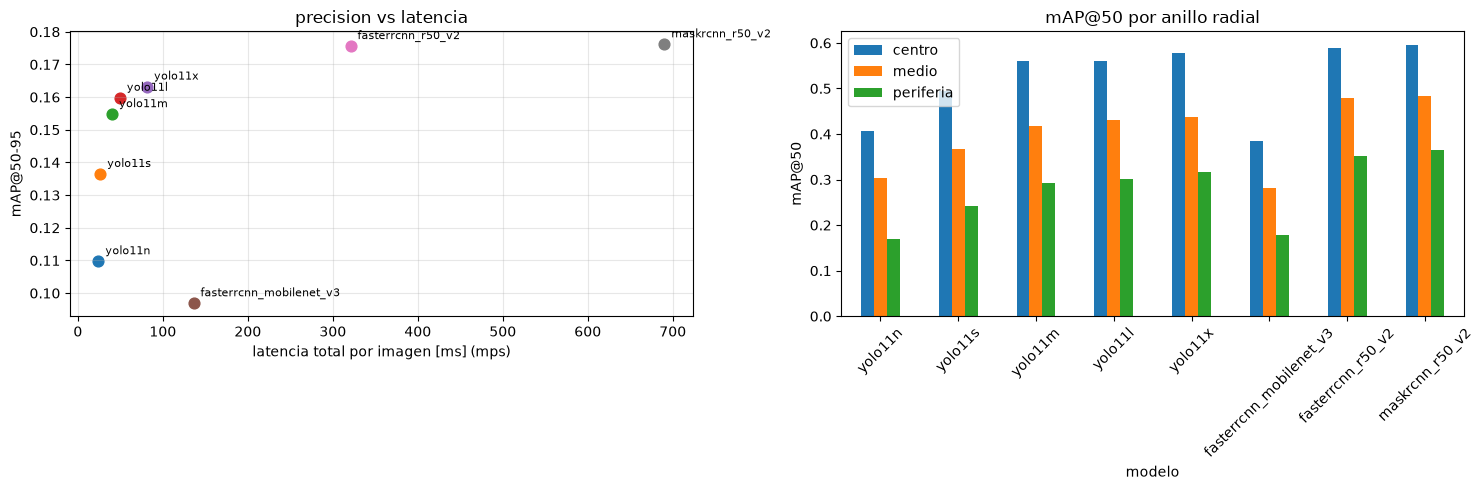

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
for nombre, f in resultados.iterrows():
    axs[0].scatter(f["ms_total"], f["mAP50-95"], s=60)
    axs[0].annotate(nombre, (f["ms_total"], f["mAP50-95"]), textcoords="offset points", xytext=(5, 5), fontsize=8)
axs[0].set_xlabel(f"latencia total por imagen [ms] ({DEVICE})")
axs[0].set_ylabel("mAP@50-95")
axs[0].set_title("precision vs latencia")
axs[0].grid(alpha=0.3)

resultados[[f"mAP50 {a}" for a in NOMBRES_ANILLOS]].plot.bar(ax=axs[1], rot=45)
axs[1].set_ylabel("mAP@50")
axs[1].set_title("mAP@50 por anillo radial")
axs[1].legend(NOMBRES_ANILLOS)
plt.tight_layout()
plt.savefig(SALIDAS / "precision_latencia_anillos.png", dpi=150)
plt.show()

#### Por cámara

Las cámaras laterales (MVL, MVR) apuntan hacia abajo y ven casi todo en la periferia, mientras que la frontal y la trasera tienen la calle en el centro. Separo el mAP@50 por cámara para ver si la proyección ayuda a todas por igual.

In [15]:
por_cam = pd.DataFrame({
    nombre: {cam: evaluar(p, test[test["camera"] == cam])[0] for cam in sorted(test["camera"].unique())}
    for nombre, p in preds.items()
}).T
por_cam.round(3)

,FV,MVL,MVR,RV
yolo11n,0.363,0.231,0.246,0.352
yolo11s,0.445,0.294,0.310,0.424
yolo11m,0.498,0.353,0.363,0.474
yolo11l,0.507,0.371,0.371,0.476
yolo11x,0.506,0.383,0.379,0.495
fasterrcnn_mobilenet_v3,0.367,0.214,0.219,0.335
fasterrcnn_r50_v2,0.548,0.435,0.409,0.514
maskrcnn_r50_v2,0.549,0.446,0.414,0.523


### Conclusiones

Estos resultados salen del test completo, 1000 imágenes (247 FV, 251 MVL, 261 MVR y 241 RV) con 11910 cajas, corridas en una Mac con MPS. Falta compararlos contra la rama 1 con la misma resolución.

Los modelos con mejor mAP son los de dos etapas, Mask R-CNN con 0.478 de mAP@50 y 0.176 de mAP@50-95, y Faster R-CNN R50 con 0.474 y 0.176. El problema es que tardan 690 y 321 ms por imagen, muy lejos de lo que puede correr una ECU. Me quedo con YOLO11m, que está en el codo de la curva, logra 0.418 de mAP@50 (el 87% de Mask R-CNN) en 40 ms por imagen, unos 25 FPS, con el 6% de la latencia. YOLO11x le gana a YOLO11l por 0.010 de mAP@50 y tarda un 65% más (82 contra 50 ms), así que no lo elegiría. Faster R-CNN con MobileNetV3 queda por debajo de YOLO11n en precisión (0.278 contra 0.295) y es más de cinco veces más lento, entonces cambiar a un backbone liviano no alcanza para que un modelo de dos etapas compita con YOLO.

La proyección cilíndrica no elimina la caída hacia los bordes. En todos los modelos el mAP@50 baja del centro a la periferia, un 58% en YOLO11n (0.406 → 0.170), un 48% en YOLO11m (0.560 → 0.292) y un 39-40% en Faster y Mask R-CNN (≈0.59 → ≈0.36). Los modelos más grandes pierden menos, y en términos relativos es en la periferia donde más ayuda el tamaño, de YOLO11n a YOLO11x el mAP@50 del centro sube un 42% (0.406 → 0.577) y el de la periferia un 86% (0.170 → 0.317). Es interesante notar que en la periferia lo que más se pierde es la localización. En YOLO11m el cociente mAP@50-95 / mAP@50 es 0.53 en el centro y 0.34 en la periferia, lo que coincide con que la caja axis-aligned que encierra el contorno reproyectado queda más grande que la del ground truth en los bordes. Si esta caída es menor que la de la rama 1 lo vamos a saber recién al comparar las dos.

La frontal y la trasera andan mejor que las laterales en todos los modelos (YOLO11m: 0.498 FV y 0.474 RV, contra 0.353 MVL y 0.363 MVR). Parte de esa diferencia viene del recorte, la banda de ±45° cubre el 95.7% de las cajas en total, pero solo el 82.8% de los vehículos en MVR y el 91.2% en MVL. Esto pasa porque las laterales miran hacia abajo y los autos estacionados al lado quedan por debajo de la banda.

Con los mapas precalculados, el `remap` cuesta entre 1.7 y 1.9 ms por imagen y la reproyección de las cajas entre 1.3 y 2.4 ms. En YOLO11m eso es el 8% de la latencia total (3.1 de 40 ms) y en YOLO11n el 15%, porque ahí la inferencia es más corta. Para una ECU me parece un costo aceptable, ya que el remap es una tabla de lookup fija por cámara.

Como trabajo futuro probaría bandas de elevación más amplias hacia abajo para las laterales, validadas en train y no en test, y una máscara del ego-vehículo para sacar los falsos `vehicle` sobre la carrocería de la FV. También reproyectaría el contorno completo en lugar de la caja que lo encierra, para no perder IoU en la periferia.